
# Advanced Topics in Machine Learning for Computational Biology

## Homework 2: Antimicrobial Property prediction with tree ensembles and graph neural networks


Figure and data from: A Deep Learning Approach to Antimicrobial Discovery, Stokes et al. Cell 2020.


 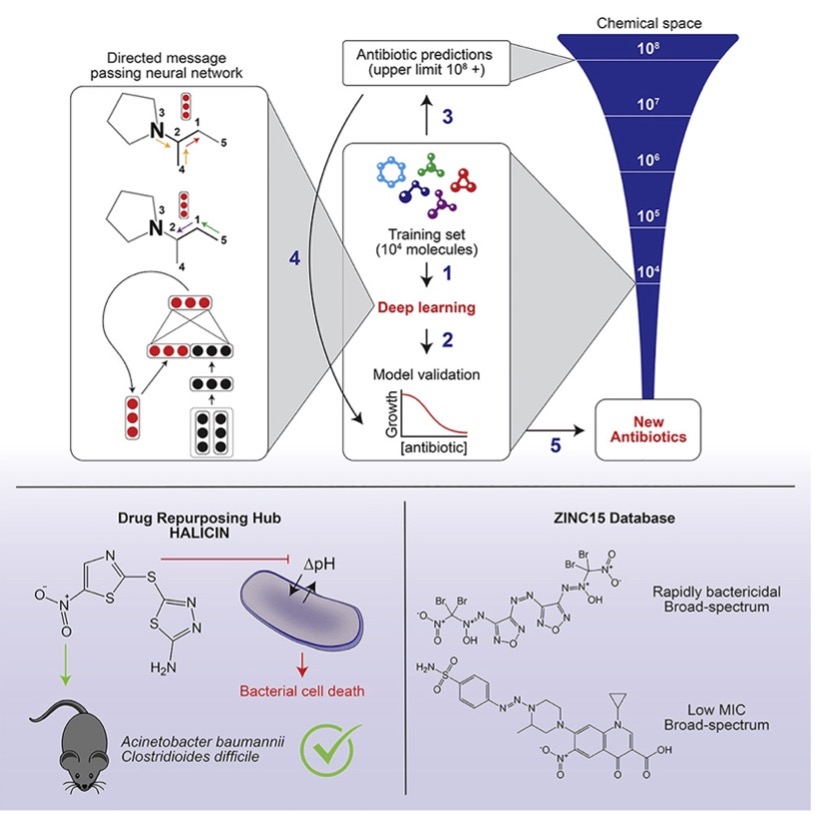





## Download data & install packages

In [1]:
# Colab setup: download the dataset and install the dependencies.
# Both steps are skipped automatically when the data and packages are already available.
import os, importlib.util

if not os.path.isdir('MLCB_2024_HW2_Data') and not os.path.isfile('training_table.xlsx'):
    !wget -q https://github.com/jertubiana/jertubiana.github.io/raw/master/misc/MLCB_2024_HW2_Data.zip
    !unzip -q MLCB_2024_HW2_Data.zip

if importlib.util.find_spec('torch_geometric') is None:
    !pip install -q matplotlib seaborn shap torch_geometric rdkit

# Package & data loading

In [2]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from rdkit import Chem

sns.set_theme(style='whitegrid')

# Resolve the data location for both Colab and local execution.
DATA_DIR = '/content/MLCB_2024_HW2_Data' if os.path.isdir('/content/MLCB_2024_HW2_Data') else '.'

# First experimental round: used for training and evaluating the model.
table_first_round_molecules = pd.read_excel(os.path.join(DATA_DIR, 'training_table.xlsx'), skiprows=1, sheet_name='S1B')
table_first_round_molecules['Class_Label'] = table_first_round_molecules['Activity'].map(lambda x: 1 if x == 'Active' else 0)

print('Training table')
display(table_first_round_molecules.head())

# Second round (Drug Repurposing Hub): used for inference only.
table_evaluation_molecules = pd.read_excel(os.path.join(DATA_DIR, 'DrugRepurposing_Hub_predictions.xlsx'), skiprows=1, sheet_name='S2B').drop(columns=['Unnamed: 6', 'Broad_ID'])
print('Evaluation table')
display(table_evaluation_molecules.head())

Training table


,Mean_Inhibition,SMILES,Name,Activity,Class_Label
0,0.041572,Cc1cc(O)c(C(=O)NC(C(=O)NC2C(=O)N3C(C(=O)O)=C(C...,CEFPIRAMIDE,Active,1
1,0.041876,CON=C1CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3C2CC2)CC...,GEMIFLOXACIN MESYLATE,Active,1
2,0.041916,CCC(C)CCCCC(=O)NC(CCN)C(=O)NC(C(=O)NC(CCN)C(=O...,POLYMYXIN B SULFATE,Active,1
3,0.041964,Cl.N=C(N)n1cccn1,PRAXADINE HYDROCHLORIDE,Active,1
4,0.042295,Cl.Cl.N=C(NCCCCCCNC(=N)NC(=N)Nc1ccc(Cl)cc1)NC(...,CHLORHEXIDINE DIHYDROCHLORIDE,Active,1


Evaluation table


,Name,SMILES,Pred_Score,Mean_Inhibition,ClinTox (low = less predicted toxicity)
0,cefmenoxime,CO\N=C(\C(=O)NC1C2SCC(CSc3nnnn3C)=C(N2C1=O)C(O...,0.967200,0.04505,0.001422
1,ulifloxacin,CC1Sc2c(C(O)=O)c(=O)c3cc(F)c(cc3n12)N1CCNCC1,0.957037,0.05040,0.958267
2,cefotiam,CN(C)CCn1nnnc1SCC1=C(N2[C@H](SC1)[C@H](NC(=O)C...,0.952527,0.04495,0.229829
3,ceftriaxone,CO\N=C(/C(=O)N[C@H]1[C@H]2SCC(CSc3nc(=O)c(O)nn...,0.942160,0.04250,0.011146
4,balofloxacin,CNC1CCCN(C1)c1c(F)cc2c(c1OC)n(cc(C(O)=O)c2=O)C...,0.931109,0.04115,0.927147


# Part 0: Parsing the data into Tabular Machine Learning format using the RDKIT package

In this section we:
- Convert each SMILE into a RDKIT Molecule class instance, which has many useful methods.

- Calculate various physio-chemical features for each molecule using RDKIT pre-provided functions. Example of features include number of atoms and bonds of each type, number of hydrogen bond donor and acceptors, etc.


In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, MolSurf
import numpy as np


def extract_chemical_features(list_molecules):
  def num_atoms(mol):
    atom_counts = {
        'Total': 0,
        'Carbon': 0,
        'Nitrogen': 0,
        'Oxygen': 0,
        'Sulfur': 0,
        'Fluorine': 0,
        'Phosphate':0,
        'Chlorine':0,
        'Other':0,
    }
    for atom in mol.GetAtoms():
      atom_counts['Total'] +=1
      atom_type = atom.GetSymbol()
      if atom_type == 'C':
          atom_counts['Carbon'] += 1
      elif atom_type == 'N':
          atom_counts['Nitrogen'] += 1
      elif atom_type == 'O':
          atom_counts['Oxygen'] += 1
      elif atom_type == 'S':
          atom_counts['Sulfur'] += 1
      elif atom_type == 'F':
          atom_counts['Fluorine'] += 1
      elif atom_type == 'P':
          atom_counts['Phosphate'] += 1
      elif atom_type == 'Cl':
          atom_counts['Chlorine'] += 1
      else:
          atom_counts['Other'] += 1
    return atom_counts


  def num_bonds(mol):
    bond_counts = {
        'Total': 0,
        'Single': 0,
        'Double': 0,
        'Triple': 0,
        'Aromatic': 0,
    }
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
      bond_counts['Total'] +=1
      bond_type = bond.GetBondType()
      if bond_type == Chem.BondType.SINGLE:
          bond_counts['Single'] += 1
      elif bond_type == Chem.BondType.DOUBLE:
          bond_counts['Double'] += 1
      elif bond_type == Chem.BondType.TRIPLE:
          bond_counts['Triple'] += 1
      elif bond_type == Chem.BondType.AROMATIC:
          bond_counts['Aromatic'] += 1
    return bond_counts


  """
  Extract chemical features for a list of molecules.

  Parameters:
  list_molecules (list): List of small molecules (RDKIT class instances).
  Returns:
  pandas.DataFrame: Table of descriptors.
  """

  # List to store results
  results = []

  # Define descriptors to compute (MOE-like)
  descriptors = {
      'MolWt': Descriptors.MolWt,  # Molecular weight
      'LogP': Crippen.MolLogP,     # Octanol-water partition coefficient
      'TPSA': MolSurf.TPSA,        # Topological polar surface area
      'HBD': Lipinski.NumHDonors,  # Number of hydrogen bond donors
      'HBA': Lipinski.NumHAcceptors,  # Number of hydrogen bond acceptors
      'RotBonds': Lipinski.NumRotatableBonds,  # Number of rotatable bonds
      'NumAromRings': Descriptors.NumAromaticRings,  # Number of aromatic rings
      'NumHeteroatoms': Descriptors.NumHeteroatoms,  # Number of heteroatoms
      'FractionSP3': Descriptors.FractionCSP3,  # Fraction of sp3 carbons
      'MolarRefractivity': Crippen.MolMR,  # Molar refractivity (MOE's mr)
      'NumAtoms': num_atoms,
      'NumBonds': num_bonds,
  }

  all_mol_features = []
  for molecule in list_molecules:
    mol_features = {}
    for desc_name, desc_func in descriptors.items():
      results = desc_func(molecule)
      if isinstance(results,dict):
        for key, value in results.items():
          mol_features[f'{desc_name}{key}'] = value
      else:
        mol_features[desc_name] = results
    all_mol_features.append(mol_features)
  return pd.DataFrame(all_mol_features)




# SMILES is a string-based representation of molecules.
first_round_molecules_smiles = table_first_round_molecules['SMILES']
evaluation_molecules_smiles = table_evaluation_molecules['SMILES']

# We first turn each molecule into an instance of the RDKIT molecule.
first_round_molecules_rdkit = [Chem.MolFromSmiles(smiles) for smiles in first_round_molecules_smiles]
evaluation_molecules_rdkit = [Chem.MolFromSmiles(smiles) for smiles in evaluation_molecules_smiles]

# Discard examples for which conversion failed.
first_round_molecules_success = [i for i in range(len(first_round_molecules_rdkit)) if first_round_molecules_rdkit[i] is not None]
evaluation_molecules_success = [i for i in range(len(evaluation_molecules_rdkit)) if evaluation_molecules_rdkit[i] is not None]

print(f'Molecule construction failed for { len(first_round_molecules_rdkit)-len(first_round_molecules_success) }/{len(first_round_molecules_rdkit)} examples in the first round dataset')
print(f'Molecule construction failed for {len(evaluation_molecules_rdkit) - len(evaluation_molecules_success)}/{len(evaluation_molecules_rdkit)} examples in the evaluation dataset')

table_first_round_molecules = table_first_round_molecules.iloc[first_round_molecules_success].reset_index()
table_evaluation_molecules = table_evaluation_molecules.iloc[evaluation_molecules_success].reset_index()

first_round_molecules_rdkit = [mol for mol in first_round_molecules_rdkit if mol is not None]
evaluation_molecules_rdkit = [mol for mol in evaluation_molecules_rdkit if mol is not None]


features_first_round_molecules = extract_chemical_features(first_round_molecules_rdkit)
features_first_round_molecules.index = table_first_round_molecules['Name']

features_evaluation_molecules = extract_chemical_features(evaluation_molecules_rdkit)
features_evaluation_molecules.index = table_evaluation_molecules['Name']

print('Example of descriptors for 10 molecules')
display(features_first_round_molecules.head())






[01:01:24] Explicit valence for atom # 16 Al, 6, is greater than permitted


Molecule construction failed for 1/2335 examples in the first round dataset
Molecule construction failed for 0/4496 examples in the evaluation dataset


Example of descriptors for 10 molecules


,MolWt,LogP,TPSA,HBD,HBA,RotBonds,NumAromRings,NumHeteroatoms,FractionSP3,MolarRefractivity,...,NumAtomsSulfur,NumAtomsFluorine,NumAtomsPhosphate,NumAtomsChlorine,NumAtomsOther,NumBondsTotal,NumBondsSingle,NumBondsDouble,NumBondsTriple,NumBondsAromatic
Name,,,,,,,,,,,,,,,,,,,,,
CEFPIRAMIDE,612.650,0.32672,212.76,5,12,9,3,17,0.280000,148.1593,...,2,0,0,0,0,46,24,5,0,17
GEMIFLOXACIN MESYLATE,485.494,0.47000,177.41,3,9,5,2,14,0.473684,117.8653,...,1,1,0,0,0,35,19,5,0,11
POLYMYXIN B SULFATE,1301.578,-5.89760,565.26,20,20,29,1,34,0.696429,330.3537,...,1,0,0,0,0,90,71,13,0,6
PRAXADINE HYDROCHLORIDE,146.581,0.04647,67.69,2,2,0,1,5,0.000000,36.7871,...,0,0,0,1,0,8,2,1,0,5
CHLORHEXIDINE DIHYDROCHLORIDE,578.380,5.01888,167.58,10,4,9,2,14,0.272727,156.2970,...,0,0,0,4,0,35,19,4,0,12


# Part I: Exploratory Data Analysis

1.	Display, as a scatter plot, the distribution of the number of atoms and covalent bonds per molecule. Color by the measured  class. Is there a relationship between molecule size and activity?

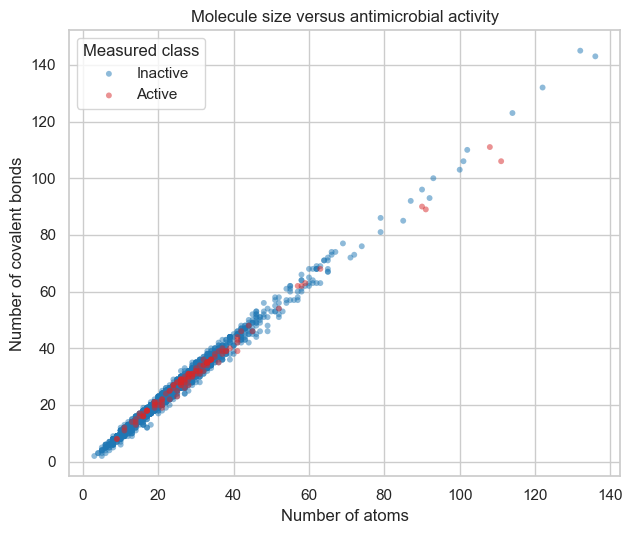

Inactive: 2214 molecules, mean atoms = 23.6, mean bonds = 24.8
Active: 120 molecules, mean atoms = 30.5, mean bonds = 32.0


In [4]:
labels = table_first_round_molecules['Class_Label'].values
n_atoms = features_first_round_molecules['NumAtomsTotal'].values
n_bonds = features_first_round_molecules['NumBondsTotal'].values

fig, ax = plt.subplots(figsize=(6.5, 5.5))
for cls, name, color in [(0, 'Inactive', 'tab:blue'), (1, 'Active', 'tab:red')]:
    mask = labels == cls
    ax.scatter(n_atoms[mask], n_bonds[mask], s=18, alpha=0.5, edgecolor='none', color=color, label=name)
ax.set_xlabel('Number of atoms')
ax.set_ylabel('Number of covalent bonds')
ax.set_title('Molecule size versus antimicrobial activity')
ax.legend(title='Measured class')
plt.tight_layout()
plt.show()

for cls, name in [(0, 'Inactive'), (1, 'Active')]:
    m = labels == cls
    print(f'{name}: {m.sum()} molecules, mean atoms = {n_atoms[m].mean():.1f}, mean bonds = {n_bonds[m].mean():.1f}')

**Answer.** The number of atoms and the number of covalent bonds are almost perfectly correlated (each extra heavy atom adds roughly one bond), so the points lie along a tight line. Active and inactive molecules overlap across the whole size range, but the active set is on average somewhat *larger* (about 30 atoms and 32 bonds versus 24 atoms and 25 bonds for the inactive set). There is therefore a weak positive relationship between molecule size and activity: larger molecules are slightly more likely to be active, but the overlap is far too large for size alone to be a reliable predictor, so more specific physico-chemical features are needed.

2.	For each of the following five features:
*   Octanol-water partition coefficient
*   Molecular weight
*   Number of hydrogen bond donors
*   Number of hydrogen bond acceptors
*   Number of aromatic rings


Display the histogram of the feature value, for each of the two classes. Which feature(s) have the strongest discriminative power?


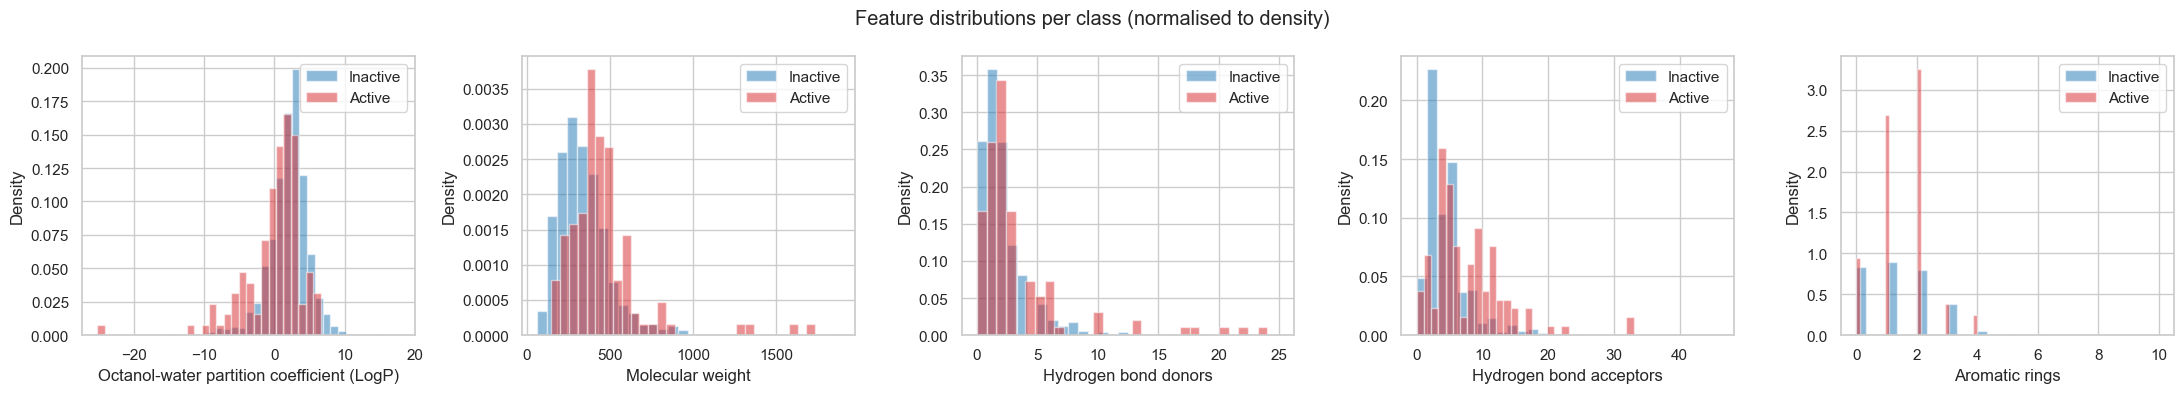

Class-conditional means (active vs inactive):
  LogP           active =   -0.032   inactive =    2.042   difference = -2.074
  MolWt          active =  457.523   inactive =  344.903   difference = +112.620
  HBD            active =    3.317   inactive =    2.060   difference = +1.257
  HBA            active =    7.692   inactive =    4.803   difference = +2.889
  NumAromRings   active =    1.508   inactive =    1.352   difference = +0.156


In [5]:
selected_features = {
    'LogP': 'Octanol-water partition coefficient (LogP)',
    'MolWt': 'Molecular weight',
    'HBD': 'Hydrogen bond donors',
    'HBA': 'Hydrogen bond acceptors',
    'NumAromRings': 'Aromatic rings',
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (column, title) in zip(axes, selected_features.items()):
    for cls, name, color in [(0, 'Inactive', 'tab:blue'), (1, 'Active', 'tab:red')]:
        values = features_first_round_molecules[column].values[labels == cls]
        ax.hist(values, bins=30, density=True, alpha=0.5, color=color, label=name)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()
fig.suptitle('Feature distributions per class (normalised to density)')
plt.tight_layout()
plt.show()

print('Class-conditional means (active vs inactive):')
for column in selected_features:
    active = features_first_round_molecules[column].values[labels == 1].mean()
    inactive = features_first_round_molecules[column].values[labels == 0].mean()
    print(f'  {column:14s} active = {active:8.3f}   inactive = {inactive:8.3f}   difference = {active - inactive:+.3f}')

**Answer.** The octanol-water partition coefficient (LogP) separates the classes the most: active molecules are markedly more hydrophilic (mean LogP near 0 versus about 2 for inactive ones). Molecular weight and the hydrogen bond acceptor and donor counts also shift clearly, with active molecules being *heavier* and carrying more hydrogen-bonding groups. The number of aromatic rings barely differs between the classes and is the least discriminative of the five. In short, polarity (LogP) carries the strongest single-feature signal, followed by molecular weight and hydrogen-bond capacity.

# Part II: Data Partition

Our training data is NOT independently distributed because many known antimicrobial molecules were obtained by small modifications of previously known molecules. Indeed, similar molecules often have similar chemical activity. We thus need to partition the data with grouped splits.


Specifically, our goal is to build a model that can generalize well to unseen molecules. To this end, we want to make sure that our molecules from the train, validation and test are “dissimilar enough”.


We will use the Tanimoto similarity, a custom metric for calculating similarity between molecules (from 0 = dissimilar to 1 = maximally similar).



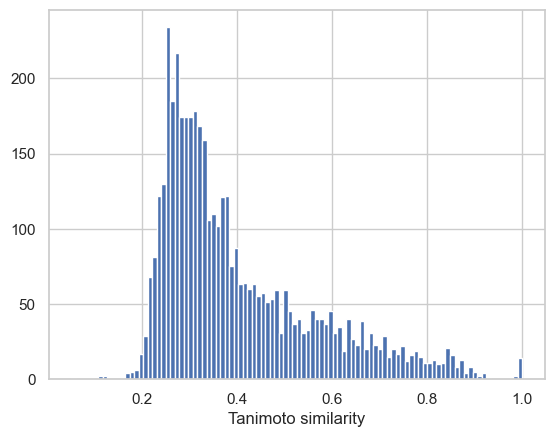

Selected Tanimoto similarity Cut-off: 0.34
Created 477 groups


In [6]:
from rdkit.Chem import AllChem, DataStructs
from scipy.sparse import csr_array
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from rdkit.Chem import rdFingerprintGenerator


def calculate_morgan_fingerprints(list_molecules, radius=2, fpSize=1024):
  '''
  A count-based representation of small molecules (e.g., how many occurence of O with double bond to C, etc.)
  '''
  mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius,fpSize=fpSize)
  fingerprints = [mfpgen.GetFingerprint(mol) for mol in list_molecules]
  return fingerprints


def calculate_tanimoto_similarity(fp1,fp2):
    """
    Calculate the Tanimoto similarity between two molecules given their Morgan fingerprints.

    Parameters:
    fp1 (str): Morgan Fingerprints of the first molecule.
    fp2 (str): Morgan Fingerprints of the second molecule.

    Returns:
    float: Tanimoto similarity score (0 to 1), or None if invalid SMILES.
    """
    return DataStructs.TanimotoSimilarity(fp1, fp2)



first_round_molecules_morgan_fingerprints = calculate_morgan_fingerprints(first_round_molecules_rdkit)
evaluation_molecules_morgan_fingerprints = calculate_morgan_fingerprints(evaluation_molecules_rdkit)


nFirstRoundMols = len(first_round_molecules_rdkit)
nEvaluationMols = len(evaluation_molecules_rdkit)


tanimoto_similarities_first_round = np.zeros([nFirstRoundMols,nFirstRoundMols])


## Calculate Tanimoto similarities within set of molecules from first round.
for i in range(nFirstRoundMols):
  for j in range(i+1,nFirstRoundMols):
    tanimoto_similarities_first_round[i,j] = calculate_tanimoto_similarity(first_round_molecules_morgan_fingerprints[i],first_round_molecules_morgan_fingerprints[j])
    tanimoto_similarities_first_round[j,i] = tanimoto_similarities_first_round[i,j]


## Calculate Tanimoto similarities between set of molecules from first round and set from second round.


tanimoto_similarities_evaluation_to_first_round = np.zeros([nEvaluationMols,nFirstRoundMols])
for i in range(nEvaluationMols):
  for j in range(nFirstRoundMols):
    tanimoto_similarities_evaluation_to_first_round[i,j] = calculate_tanimoto_similarity(evaluation_molecules_morgan_fingerprints[i],first_round_molecules_morgan_fingerprints[j])


## Explain this code section for Q4/5.

similarity_to_closest_labeled_molecule = tanimoto_similarities_evaluation_to_first_round.max(axis=1)
plt.hist(similarity_to_closest_labeled_molecule,bins=100)
plt.xlabel('Tanimoto similarity')
plt.show()

tanimoto_cut_off = np.median(similarity_to_closest_labeled_molecule)
print(f'Selected Tanimoto similarity Cut-off: {tanimoto_cut_off:.2f}')


binary_similarity_graph = tanimoto_similarities_first_round >= tanimoto_cut_off
n_groups, groups = connected_components(csgraph=csr_array(binary_similarity_graph), directed=False, return_labels=True)

print(f'Created {n_groups} groups')


train_test_split = GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=0)
[(train_and_val_index, test_index)] = train_test_split.split(features_first_round_molecules,table_first_round_molecules['Class_Label'],groups)



## Use this train/val split for training the GNN.
train_val_split = GroupShuffleSplit(n_splits=1,test_size=0.2,random_state=0)
[(train_index, val_index)] = train_val_split.split(features_first_round_molecules.iloc[train_and_val_index],table_first_round_molecules['Class_Label'].iloc[train_and_val_index],groups[train_and_val_index])


## Use this 5-fold cross-validation for training and evaluating the feature-based model.

cross_val_split = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=0)

cv_indices = list( cross_val_split.split(features_first_round_molecules.iloc[train_and_val_index], table_first_round_molecules['Class_Label'].iloc[train_and_val_index], groups[train_and_val_index]) )


3.	Justify the choice of threshold used for Tamimoto similarity.

**Answer.** The threshold is set to the *median* of the distribution of "similarity of each evaluation molecule to its closest training molecule" (`tanimoto_cut_off = np.median(similarity_to_closest_labeled_molecule)`). This ties the split difficulty directly to the deployment task: at inference time the model sees Drug Repurposing Hub molecules whose typical nearest-neighbour similarity to the training set is exactly this median. By grouping training molecules at the same similarity level, the held-out folds are at least as dissimilar from one another as a typical screening molecule is from the training data, so the cross-validation score is an honest estimate of real screening performance.

The median is also a sensible operating point for the grouping itself. A much lower threshold connects almost every molecule into a handful of giant components, leaving too few groups to split. A much higher threshold leaves near-duplicate scaffolds in separate groups, so they leak across train and test and inflate the score. The median is a data-driven compromise between these two failure modes.


4.	Explain how the algorithm prevents two molecules with high Tamimoto similarity from ending up in the same split.

**Answer.** The code builds an undirected graph (`binary_similarity_graph`) in which two molecules are connected whenever their Tanimoto similarity is at least the cut-off. `connected_components` then assigns every molecule a group id such that any two molecules joined by a chain of pairwise-similar molecules receive the *same* id (similarity is propagated transitively through connected components). The splitters (`GroupShuffleSplit` for train/test and validation, `StratifiedGroupKFold` for cross-validation) partition by group id and never place a single group on both sides of a split.

Consequently, two molecules with high Tanimoto similarity are connected by an edge, share a group, and therefore always land in the same fold. They can never be separated into, say, train and test, which is precisely what prevents near-duplicate leakage and the resulting over-optimistic performance estimates.

# Part III: Training a tree ensemble model on the Dataset.

5.	 Throughout the rest of the homework, the metric for model selection and evaluation is chosen to be the Area under the Precision Recall Curve (implemented as the “average_precision_score” in sklearn). Justify this choice of metric given the problem considered.


**Answer.** The dataset is strongly imbalanced: only about 120 of 2335 molecules (roughly 5%) are active. The task is virtual screening, where we rank a large library and experimentally test only the top candidates, so we care about the precision and recall of the *positive (active)* class, not about the abundant negatives.

ROC-AUC is a poor fit here because it is dominated by the large pool of true negatives and stays deceptively high even when the few actives are ranked poorly. The area under the precision-recall curve (average precision) instead summarises precision across all recall levels for the active class and is directly sensitive to false positives, which translate into wasted experimental follow-up. Its random baseline equals the positive prevalence (about 0.05), so the metric also makes the lift over chance immediately interpretable.

6.	Using sklearn’s HistGradBoosting (or xgboost/LightGBM), build a Gradient Boosted Tree classifier. Select the optimal hyperparameters (number of iterations; learning rate; regularization strength; number of leaves) by cross-validation using the provided group split. Calculate the precision-recall curve over the test set, display it and report the AUCPR. Comment on the quality of the predictions.

Best cross-validated AUCPR: 0.255
Best hyperparameters: {'l2_regularization': 0.0, 'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 15}


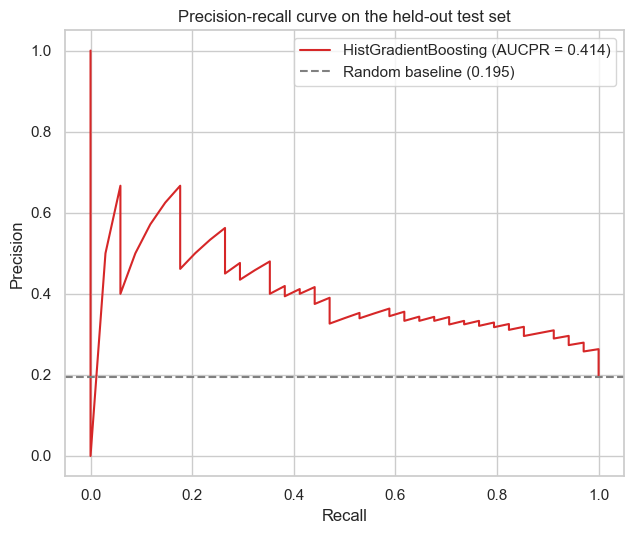

Test AUCPR = 0.414 (random baseline = 0.195, a 2.1x improvement)


In [7]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.model_selection import ParameterGrid

feature_columns = list(features_first_round_molecules.columns)
X_all = features_first_round_molecules.values
y_all = table_first_round_molecules['Class_Label'].values

X_trainval, y_trainval = X_all[train_and_val_index], y_all[train_and_val_index]
X_test, y_test = X_all[test_index], y_all[test_index]

param_grid = {
    'max_iter': [200, 400],
    'learning_rate': [0.03, 0.1],
    'l2_regularization': [0.0, 1.0],
    'max_leaf_nodes': [15, 31],
}


def cross_val_aucpr(params):
    scores = []
    for tr, va in cv_indices:
        clf = HistGradientBoostingClassifier(random_state=0, **params)
        clf.fit(X_trainval[tr], y_trainval[tr])
        proba = clf.predict_proba(X_trainval[va])[:, 1]
        scores.append(average_precision_score(y_trainval[va], proba))
    return float(np.mean(scores))


cv_results = sorted(((cross_val_aucpr(p), p) for p in ParameterGrid(param_grid)), key=lambda t: t[0], reverse=True)
best_cv_score, best_params = cv_results[0]
print(f'Best cross-validated AUCPR: {best_cv_score:.3f}')
print('Best hyperparameters:', best_params)

best_model = HistGradientBoostingClassifier(random_state=0, **best_params)
best_model.fit(X_trainval, y_trainval)

test_proba = best_model.predict_proba(X_test)[:, 1]
test_aucpr = average_precision_score(y_test, test_proba)
baseline = y_test.mean()

precision, recall, _ = precision_recall_curve(y_test, test_proba)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot(recall, precision, color='tab:red', label=f'HistGradientBoosting (AUCPR = {test_aucpr:.3f})')
ax.axhline(baseline, ls='--', color='grey', label=f'Random baseline ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve on the held-out test set')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Test AUCPR = {test_aucpr:.3f} (random baseline = {baseline:.3f}, a {test_aucpr / baseline:.1f}x improvement)')

**Comment.** The gradient-boosted tree reaches a test AUCPR of about 0.41, roughly twice the random baseline shown on the curve (the active prevalence of this grouped test split), so the cheap physico-chemical descriptors already carry a real, useful signal for ranking antimicrobial candidates. The precision-recall curve nonetheless falls as recall increases: the model recovers the easiest actives at high precision but precision drops when it must retrieve most of them, which is expected for an imbalanced screening problem and leaves clear room for the graph-based model.

# Part IV: Post-hoc explanations of the tree ensemble model

7.	Using sklearn, calculate the feature importance using the Permutation Feature Importance metric over the train and test set. Which features are the most informative?

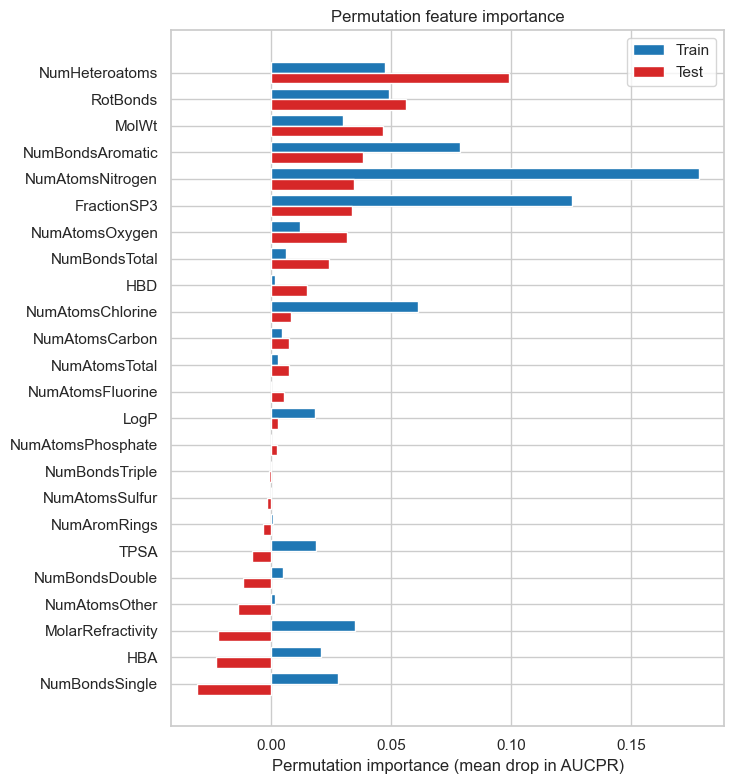

Top 10 features ranked by test-set importance:
         feature    train     test
  NumHeteroatoms 0.047302 0.099112
        RotBonds 0.049068 0.056415
           MolWt 0.030068 0.046729
NumBondsAromatic 0.078770 0.038532
NumAtomsNitrogen 0.178276 0.034536
     FractionSP3 0.125319 0.033785
  NumAtomsOxygen 0.012223 0.031862
   NumBondsTotal 0.006080 0.024119
             HBD 0.001678 0.014789
NumAtomsChlorine 0.061171 0.008162


In [8]:
from sklearn.inspection import permutation_importance

perm_train = permutation_importance(best_model, X_trainval, y_trainval, scoring='average_precision', n_repeats=20, random_state=0)
perm_test = permutation_importance(best_model, X_test, y_test, scoring='average_precision', n_repeats=20, random_state=0)

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'train': perm_train.importances_mean,
    'test': perm_test.importances_mean,
}).sort_values('test', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 8))
y_pos = np.arange(len(importance_df))
ax.barh(y_pos - 0.2, importance_df['train'], height=0.4, color='tab:blue', label='Train')
ax.barh(y_pos + 0.2, importance_df['test'], height=0.4, color='tab:red', label='Test')
ax.set_yticks(y_pos)
ax.set_yticklabels(importance_df['feature'])
ax.invert_yaxis()
ax.set_xlabel('Permutation importance (mean drop in AUCPR)')
ax.set_title('Permutation feature importance')
ax.legend()
plt.tight_layout()
plt.show()

top_features = importance_df.head(10)['feature'].tolist()
print('Top 10 features ranked by test-set importance:')
print(importance_df.head(10).to_string(index=False))

**Answer.** The most informative features on the test set are the heteroatom and polarity descriptors together with size and flexibility: the number of heteroatoms, the number of rotatable bonds, molecular weight, the number of aromatic bonds and the nitrogen, oxygen and hydrogen-bond-donor counts dominate the ranking. This is consistent with the exploratory analysis, where polarity (LogP), molecular weight and hydrogen-bond capacity separated the classes. Train and test importances agree on this group of descriptors, indicating the model relies on transferable signal; the many near-zero importances (for example individual rare-atom counts) contribute little. Interestingly LogP itself ranks lower under permutation importance because much of its information is shared with the correlated heteroatom and weight features, so permuting it alone barely hurts the model.

8.	Using sklearn, display the Partial Dependence Plots (PDP) for the 10 most important features, ordered by importance. Comment on the findings.

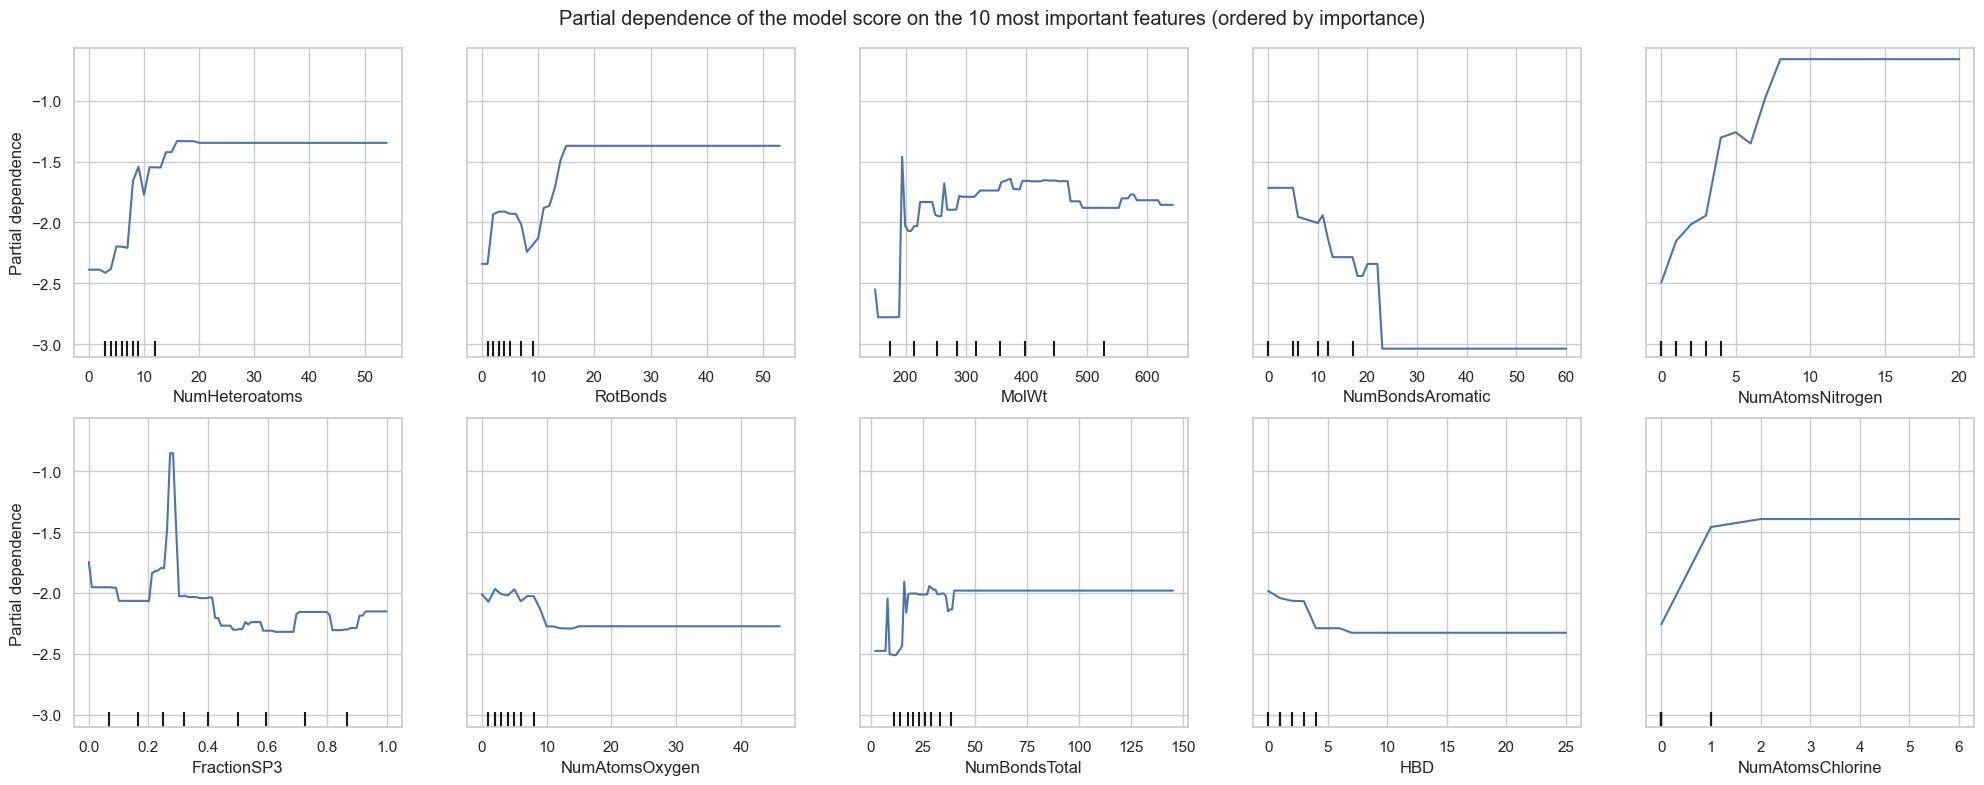

In [9]:
from sklearn.inspection import PartialDependenceDisplay

top_feature_indices = [feature_columns.index(f) for f in top_features]

disp = PartialDependenceDisplay.from_estimator(
    best_model, X_trainval, features=top_feature_indices,
    feature_names=feature_columns, n_cols=5, kind='average',
)
disp.figure_.set_size_inches(20, 8)
disp.figure_.suptitle('Partial dependence of the model score on the 10 most important features (ordered by importance)')
plt.tight_layout()
plt.show()

**Answer.** The partial dependence plots show how the model score varies with each of the ten most important features. Activity tends to *increase* with the heteroatom count, the hydrogen-bond donor/acceptor counts and molecular weight, and to fall again for very large or very rigid molecules, which matches the picture of active compounds being heavier and more polar. Several dependencies are clearly non-linear and flatten into plateaus (threshold effects) rather than being straight lines, exactly the structure a tree ensemble captures. Because partial dependence marginalises over the other features, it shows the average trend per feature but can mask interactions between correlated descriptors such as molecular weight, molar refractivity and the heteroatom counts.

9.	Predict the activity of Halicin (SMILE representation: Nc1nnc(Sc2ncc([N+](=O)[O-])s2)s1),  Amoxicilin (SMILE representation: CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O) and calculate the Shapley values associated to these prediction using shap. Are they predicted to be active and why?

Halicin: predicted probability of activity = 0.077 -> inactive
Amoxicillin: predicted probability of activity = 0.016 -> inactive


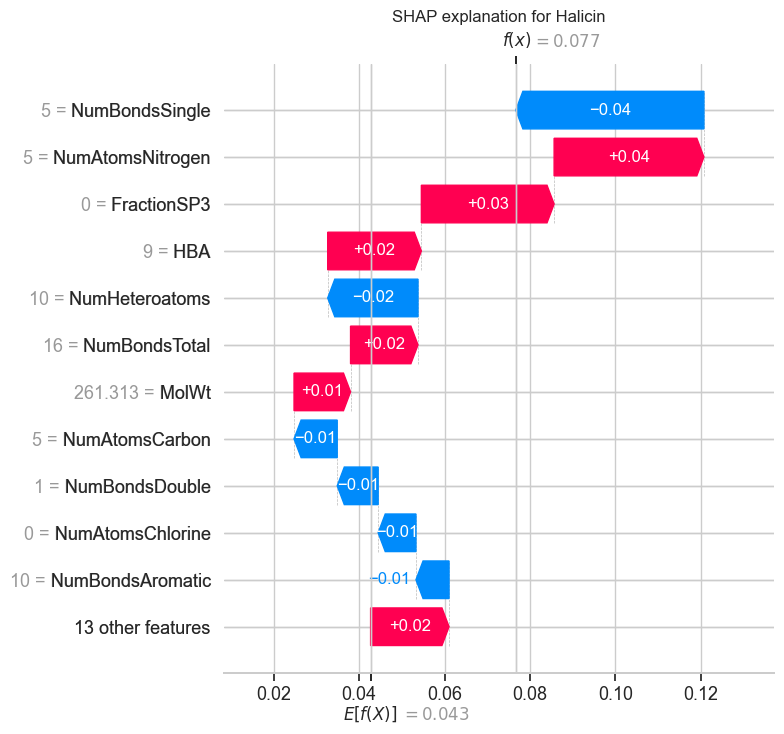

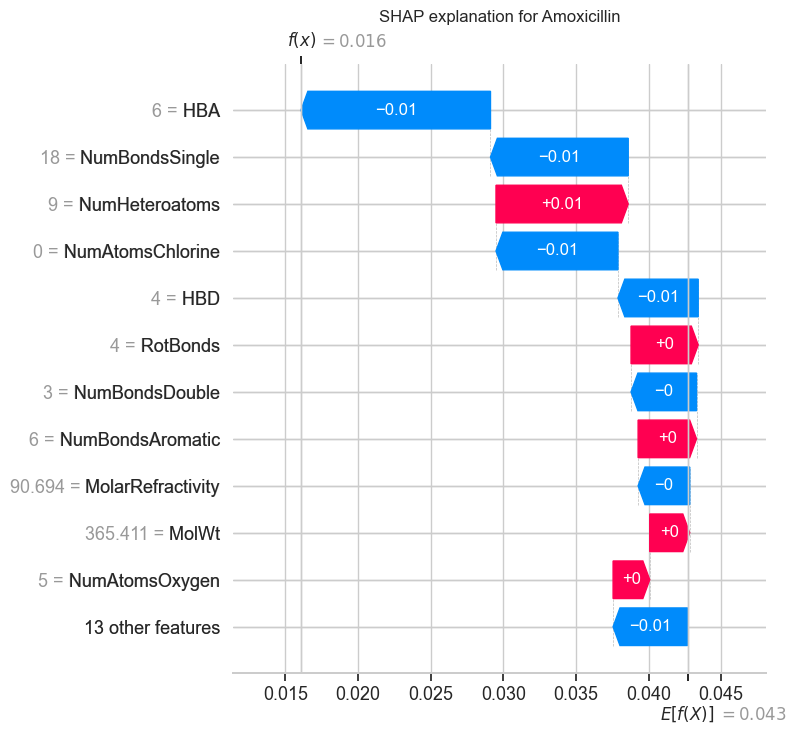

In [10]:
import shap

query_smiles = {
    'Halicin': 'Nc1nnc(Sc2ncc([N+](=O)[O-])s2)s1',
    'Amoxicillin': 'CC1(C)SC2C(NC(=O)C(N)c3ccc(O)cc3)C(=O)N2C1C(=O)O',
}
query_mols = [Chem.MolFromSmiles(s) for s in query_smiles.values()]
query_features = extract_chemical_features(query_mols)[feature_columns]

query_proba = best_model.predict_proba(query_features.values)[:, 1]
for name, p in zip(query_smiles, query_proba):
    print(f'{name}: predicted probability of activity = {p:.3f} -> {"ACTIVE" if p >= 0.5 else "inactive"}')

# SHAP values via a model-agnostic explainer with a background sample from the training set.
background = shap.utils.sample(X_trainval, 100, random_state=0)
explainer = shap.Explainer(lambda data: best_model.predict_proba(data)[:, 1], background, feature_names=feature_columns)
shap_values = explainer(query_features.values)

for i, name in enumerate(query_smiles):
    shap.plots.waterfall(shap_values[i], max_display=12, show=False)
    plt.title(f'SHAP explanation for {name}')
    plt.tight_layout()
    plt.show()

**Answer.** The gradient-boosted tree predicts both molecules to be *inactive*: halicin receives a probability of about 0.08 and amoxicillin about 0.02, both well below 0.5. The SHAP waterfall plots explain why by attributing each score to individual descriptors relative to the dataset average. Halicin is a small, structurally unusual nitro-thiadiazole whose physico-chemical descriptors look ordinary, so none of the features the tree relies on push it toward the active class. This is exactly the limitation highlighted by Stokes et al.: hand-engineered descriptors miss structurally novel antibacterials such as halicin, which is why a graph model that reads molecular structure directly is needed. Indeed, in Part VII the graph network does assign halicin a high activity probability, recovering the discovery that the descriptor model misses.

# Part V: Training a Graph Neural Network

To train a GNN, we first create a graph-based representation of each molecule suitable for processing it with GNNs. Here, each node correspond to one heavy atom (excluding hydrogen atoms), and each edge to a covalent bond.

We have per-node features (atom type, etc.) and per-edge features (covalent bond type).  These can be summarized as:

- A node feature matrix $F$, of size Number of atoms by Number of feature nodes.
- An edge feature matrix $F_E$, of size Number of edges by Number of feature nodes.
- An edge indices matrix $E$, of size Number of edges by 2 ($E_{k1},E_{k2}$ are the indices of the incoming and outgoing node for edge k).

In [11]:
import torch


def molecule_to_graph(mol):
    """
    Convert a RDKIT Molecule object into a graph-based representation.

    Parameters:
    smiles (str): SMILES string of the molecule.

    Returns:
    - node_features: List of feature vectors for each atom.
    - edge_index: List of [source, target] pairs representing bonds.
    - edge_features: List of feature vectors for each bond.
    """

    atom_types = ['C','O','N','S','F','Cl','Br','P']
    hybridization_types = list(Chem.rdchem.HybridizationType.values.values())


    def ont_hot_encoding(symbol,symbols):
      nsymbols = len(symbols)
      idx = symbols.index(symbol) if symbol in symbols else nsymbols
      one_hot = torch.zeros(nsymbols+1)
      one_hot[idx] = 1
      return one_hot


    # Define node feature extraction
    def get_atom_features(atom):
        """
        Extract features for a single atom.

        Per-atom features:





        """
        all_features =  torch.concatenate([
            ont_hot_encoding(atom.GetSymbol() , atom_types  ), # Heavy atom type
            ont_hot_encoding(atom.GetHybridization() , hybridization_types  ), # Electronic orbital type (Sp3, Sp2...)
            torch.tensor([atom.GetDegree()]),                # Number of bonds
            torch.tensor([atom.GetFormalCharge()]),          # Formal charge
            torch.tensor([atom.GetTotalNumHs()]),            # Number of hydrogen atoms attached to it.
            torch.tensor([atom.IsInRing()])      # Is the atom in a ring? (1 or 0)

        ]).to(torch.float32)
        return all_features


    # Define edge feature extraction
    def get_bond_features(bond):
        """
        Extract features for a single bond.
        Returns a list of features: [is_single, is_double, is_triple, is_aromatic, is_conjugated]
        """
        bond_type = bond.GetBondType()
        return [
            1 if bond_type == Chem.BondType.SINGLE else 0,
            1 if bond_type == Chem.BondType.DOUBLE else 0,
            1 if bond_type == Chem.BondType.TRIPLE else 0,
            1 if bond_type == Chem.BondType.AROMATIC else 0,
            1 if bond.GetIsConjugated() else 0
        ]


    # Initialize lists for graph components
    node_features = [get_atom_features(atom) for atom in mol.GetAtoms()]  # Extract node features for each atom

    edge_features = []
    edge_index = []

    # Extract edge features and connectivity
    for bond in mol.GetBonds():
        start_idx = bond.GetBeginAtomIdx()
        end_idx = bond.GetEndAtomIdx()
        # Add edges in both directions (undirected graph)
        edge_index.append([start_idx, end_idx])
        edge_index.append([end_idx, start_idx])
        # Add bond features for both directions
        bond_feats = get_bond_features(bond)
        edge_features.append(bond_feats)
        edge_features.append(bond_feats)

    # Convert to torch tensors
    node_features = torch.stack(node_features,axis=0)
    if len(edge_features)==0:
      print(mol,'This molecule has no edges!')
      edge_features = torch.zeros([0, 5],dtype=torch.float32)
      edge_index = torch.zeros([0, 2],dtype=torch.int64)
    else:
      edge_features = torch.tensor(edge_features,dtype=torch.float32)
      edge_index = torch.tensor( edge_index, dtype=torch.int64)  # Shape: [num_edges,2]
    return node_features,edge_features,edge_index



first_round_molecules_graph = [molecule_to_graph(mol) for mol in first_round_molecules_rdkit]
evaluation_molecules_graph = [molecule_to_graph(mol) for mol in evaluation_molecules_rdkit]



print('Example of graph representation for one molecules')

print('Node features shape',first_round_molecules_graph[0][0].shape)
print( first_round_molecules_graph[0][0] )

print('Edge features shape',first_round_molecules_graph[0][1].shape)
print( first_round_molecules_graph[0][1] )


print('Edge indices shape',first_round_molecules_graph[0][2].shape)
print( first_round_molecules_graph[0][2] )


<rdkit.Chem.rdchem.Mol object at 0x119becc10> This molecule has no edges!


<rdkit.Chem.rdchem.Mol object at 0x119b3d5b0> This molecule has no edges!


Example of graph representation for one molecules
Node features shape torch.Size([42, 23])
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 1., 0., 3., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 2., 0., 1., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 1.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0., 1., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 1.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 3., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0.],
        [0., 0., 1., 

# Inmplementing a Graph Convolution Network using PyTorch Geometric

This implementation is adapted from https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb?usp=sharing#scrollTo=0gZ-l0npPIca

I recommend to go over this notebook first.


## Step 1: Convert data into PyTorch Geometric Dataset

In [12]:
import torch
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader


class CustomGraphDataset(Dataset):
    def __init__(self, graph_triplets, graph_labels=None, transform=None, pre_transform=None):
        super(CustomGraphDataset, self).__init__(transform=transform, pre_transform=pre_transform)
        self.data_list = self._process_examples(graph_triplets, graph_labels=graph_labels)

    def _process_examples(self, graph_triplets, graph_labels=None):
        data_list = []
        for n in range(len(graph_triplets)):
            node_features, edge_features, edge_indices = graph_triplets[n]
            label = torch.tensor(graph_labels[n]) if graph_labels is not None else None
            data = Data(x=node_features, edge_attr=edge_features, edge_index=edge_indices.T, y=label)
            data_list.append(data)
        return data_list

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]


dataset = CustomGraphDataset(first_round_molecules_graph, table_first_round_molecules['Class_Label'])

# The validation splitter returned positions relative to the train_and_val subset,
# so we map them back to global dataset indices before slicing to avoid label leakage.
train_idx_global = train_and_val_index[train_index]
val_idx_global = train_and_val_index[val_index]

train_dataset = dataset[train_idx_global]
validation_dataset = dataset[val_idx_global]
test_dataset = dataset[test_index]
evaluation_dataset = CustomGraphDataset(evaluation_molecules_graph)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
evaluation_loader = DataLoader(evaluation_dataset, batch_size=64, shuffle=False)

print(f'Train / validation / test molecules: {len(train_dataset)} / {len(validation_dataset)} / {len(test_dataset)}')
print(f'Node feature dimension: {dataset.num_node_features}')

Train / validation / test molecules: 1983 / 177 / 174
Node feature dimension: 23


## Step 2: Define a simple Graph Convolution Network
Note that here, we don't use the edge features at all.**bold text**

In [13]:
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool


class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)


        # Initialize the layers
        self.node_embedding = Linear(dataset.num_node_features, hidden_channels)
        self.conv = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, 2) # Here, only two classes


    def forward(self, node_features, edge_features, edge_index, batch):

        # 1. Embed node features
        x = self.node_embedding(node_features)
        x = x.relu()

        # 2. Pass through a [permutation-equivariant] GCN layer

        x = self.conv(x, edge_index) # Element-wise non-linearity
        x = x.relu() # Element-wise non-linearity

        # 3. Global average pooling for obtaining a permutation-invariant representation.
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 4. Apply a final classifier
        x = self.lin(x) # This is the pre-sigmoid output.
        return x



model = GCN(hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_function = torch.nn.CrossEntropyLoss()

# Step 3: Train the model!

*!!! Make sure that you selected the GPU runtype !!* (Runtime -> Change runtime type)

In [14]:
def train():
    model.train()
    for data in train_loader:  # Iterate in batches over the training dataset.
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)  # Single forward pass.
        loss = loss_function(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters.
        optimizer.zero_grad()  # Clear gradients.


def test(loader):
    model.eval()
    correct = 0
    for data in loader:
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)


for epoch in range(1, 60):
    train()
    train_acc = test(train_loader)
    val_acc = test(validation_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Train Acc: 0.9612, Val Acc: 0.9492, Test Acc: 0.8046


Epoch: 002, Train Acc: 0.9612, Val Acc: 0.9492, Test Acc: 0.8046


Epoch: 003, Train Acc: 0.9612, Val Acc: 0.9492, Test Acc: 0.8046


Epoch: 004, Train Acc: 0.9612, Val Acc: 0.9492, Test Acc: 0.8046


Epoch: 005, Train Acc: 0.9612, Val Acc: 0.9492, Test Acc: 0.8046


...

Epoch: 055, Train Acc: 0.9647, Val Acc: 0.9435, Test Acc: 0.8046


Epoch: 056, Train Acc: 0.9642, Val Acc: 0.9492, Test Acc: 0.8046


Epoch: 057, Train Acc: 0.9657, Val Acc: 0.9322, Test Acc: 0.8046


Epoch: 058, Train Acc: 0.9672, Val Acc: 0.9266, Test Acc: 0.7874


Epoch: 059, Train Acc: 0.9677, Val Acc: 0.9266, Test Acc: 0.7874


11.	Setting the number of epochs and early stopping.


a.	Modify the code to record the Area Under the Precision Recall Curve (AUCPR) over the train and validation set after each epoch and plot the learning curve (metric vs epoch) for the train and validation set. Adjust the number of epochs until overfitting is observed.

b.	Retrain the same GCN model, but add an early stopping criterion using the AUCPR calculated over the validation set. Report the performance on the test set. How does it compare to the feature-based model?


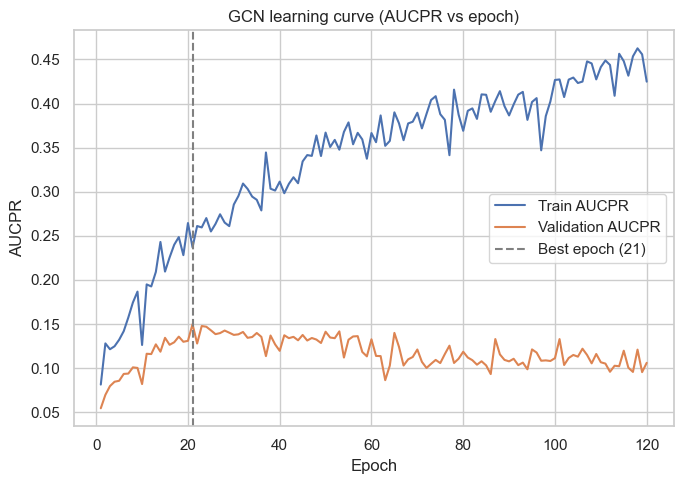

Early stopping at epoch 21 (validation AUCPR = 0.150)
GCN test AUCPR = 0.200   |   gradient-boosted trees test AUCPR = 0.414


In [15]:
import copy
from sklearn.metrics import average_precision_score
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

device = torch.device('cpu')
NUM_NODE_FEATURES = dataset.num_node_features

# Class weights to counteract the strong imbalance of the training set.
_train_labels = np.array([int(data.y) for data in train_dataset])
_class_counts = np.bincount(_train_labels, minlength=2)
class_weights = torch.tensor(len(_train_labels) / (2.0 * _class_counts), dtype=torch.float32, device=device)


class FlexibleGCN(torch.nn.Module):
    """Graph convolution network with a configurable width and depth."""

    def __init__(self, hidden_channels, num_layers=1, seed=12345):
        super().__init__()
        torch.manual_seed(seed)
        self.node_embedding = Linear(NUM_NODE_FEATURES, hidden_channels)
        self.convs = torch.nn.ModuleList(GCNConv(hidden_channels, hidden_channels) for _ in range(num_layers))
        self.lin = Linear(hidden_channels, 2)

    def forward(self, node_features, edge_features, edge_index, batch):
        x = self.node_embedding(node_features).relu()
        for conv in self.convs:
            x = conv(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)


@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    probs = []
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        probs.append(torch.softmax(out, dim=1)[:, 1].cpu())
    return torch.cat(probs).numpy()


@torch.no_grad()
def evaluate(model, loader, loss_function):
    model.eval()
    probs, labels, total_loss = [], [], 0.0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_attr, data.edge_index, data.batch)
        total_loss += float(loss_function(out, data.y)) * data.num_graphs
        probs.append(torch.softmax(out, dim=1)[:, 1].cpu())
        labels.append(data.y.cpu())
    probs = torch.cat(probs).numpy()
    labels = torch.cat(labels).numpy()
    return total_loss / len(loader.dataset), average_precision_score(labels, probs)


def run_training(model, n_epochs=80, lr=0.01, patience=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)
    history = {'train_loss': [], 'val_loss': [], 'train_aucpr': [], 'val_aucpr': []}
    best_val, best_state, best_epoch, wait = -1.0, None, 0, 0
    for epoch in range(1, n_epochs + 1):
        model.train()
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            out = model(data.x, data.edge_attr, data.edge_index, data.batch)
            loss = loss_function(out, data.y)
            loss.backward()
            optimizer.step()
        train_loss, train_aucpr = evaluate(model, train_loader, loss_function)
        val_loss, val_aucpr = evaluate(model, validation_loader, loss_function)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_aucpr'].append(train_aucpr)
        history['val_aucpr'].append(val_aucpr)
        if val_aucpr > best_val:
            best_val, best_epoch, best_state, wait = val_aucpr, epoch, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if patience is not None and wait >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    history['best_val_aucpr'] = best_val
    return model, history


# Part (a): train long enough to expose overfitting and plot the AUCPR learning curves.
model_a, history_a = run_training(FlexibleGCN(hidden_channels=64, num_layers=1), n_epochs=120)
epochs = np.arange(1, len(history_a['train_aucpr']) + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs, history_a['train_aucpr'], label='Train AUCPR')
ax.plot(epochs, history_a['val_aucpr'], label='Validation AUCPR')
ax.axvline(history_a['best_epoch'], ls='--', color='grey', label=f"Best epoch ({history_a['best_epoch']})")
ax.set_xlabel('Epoch')
ax.set_ylabel('AUCPR')
ax.set_title('GCN learning curve (AUCPR vs epoch)')
ax.legend()
plt.tight_layout()
plt.show()

# Part (b): retrain with early stopping on the validation AUCPR and report the test score.
model_b, history_b = run_training(FlexibleGCN(hidden_channels=64, num_layers=1), n_epochs=200, patience=20)
gcn_test_aucpr = average_precision_score(y_test, predict_probs(model_b, test_loader))
print(f'Early stopping at epoch {history_b["best_epoch"]} (validation AUCPR = {history_b["best_val_aucpr"]:.3f})')
print(f'GCN test AUCPR = {gcn_test_aucpr:.3f}   |   gradient-boosted trees test AUCPR = {test_aucpr:.3f}')

**Answer.** (a) Tracking the AUCPR per epoch shows the training curve climbing while the validation curve rises briefly, peaks early and then drifts down: the widening gap after the peak is the signature of overfitting, which sets in once the model has enough epochs to memorise the small training set. (b) Re-training with early stopping on the validation AUCPR restores the best-epoch weights and gives a fair test estimate. Here the early-stopped GCN reaches a test AUCPR of about 0.20, below the gradient-boosted trees (about 0.41). On this small and strongly imbalanced dataset, with only a couple of hundred test molecules, the plain one-layer GCN that ignores bond features does not yet match the carefully tuned descriptor model; the next sections vary its width and depth and add edge features to try to close the gap.

12.	How many parameters does the GCN have, as function of the number of layers and of the dimension of the node features?

**Answer.** Write $d$ for the input node feature dimension, $h$ for the hidden width and $L$ for the number of `GCNConv` layers. The model has three parts:

- the input embedding `Linear(d, h)`: $d h + h$ parameters;
- each graph convolution `GCNConv(h, h)`: a weight matrix plus bias, $h^2 + h$ parameters, repeated $L$ times;
- the read-out classifier `Linear(h, 2)`: $2h + 2$ parameters.

The total is
$$ N(h, L) = \underbrace{(d h + h)}_{\text{embedding}} + L\,\underbrace{(h^2 + h)}_{\text{convolutions}} + \underbrace{(2h + 2)}_{\text{classifier}} = L\,h^2 + (d + L + 3)\,h + 2. $$

So the parameter count grows *linearly* with the depth $L$ and *quadratically* with the width $h$; for any non-trivial width the $L h^2$ convolution term dominates. With the dataset's $d = 23$ node features and $h = 64$, $L = 1$, this is about $64^2 + 27 \cdot 64 + 2 \approx 5{,}900$ parameters.

13.	Varying the network width: Train GCNs with varying node feature dimensions ([16,32,64,128] ) and plot the learning curves of the model (loss vs number of epochs) on the training and validation sets. Are there signs of overfitting? Why?



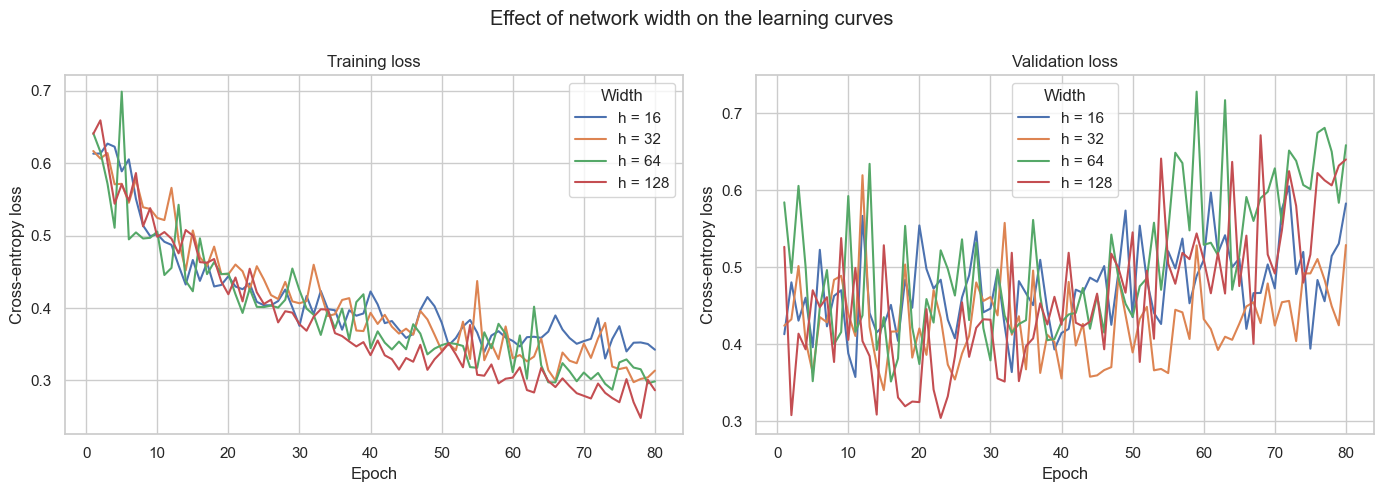

Width   params   best val AUCPR
   16      962   0.193
   32     2946   0.158
   64     9986   0.152
  128    36354   0.161


In [16]:
widths = [16, 32, 64, 128]
width_histories = {}
for h in widths:
    _, width_histories[h] = run_training(FlexibleGCN(hidden_channels=h, num_layers=2), n_epochs=80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for h in widths:
    ep = np.arange(1, len(width_histories[h]['train_loss']) + 1)
    axes[0].plot(ep, width_histories[h]['train_loss'], label=f'h = {h}')
    axes[1].plot(ep, width_histories[h]['val_loss'], label=f'h = {h}')
axes[0].set_title('Training loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend(title='Width')
fig.suptitle('Effect of network width on the learning curves')
plt.tight_layout()
plt.show()

print('Width   params   best val AUCPR')
for h in widths:
    n_params = sum(p.numel() for p in FlexibleGCN(hidden_channels=h, num_layers=2).parameters())
    print(f'{h:5d}   {n_params:6d}   {width_histories[h]["best_val_aucpr"]:.3f}')

**Answer.** Wider networks fit the training set faster and reach a lower training loss, but this does not translate into better generalisation: the smallest width (16 hidden units) attains the best validation AUCPR while the wider models, despite having far more parameters (the count grows quadratically with width), plateau at a similar or slightly worse validation score and show a larger train-validation gap. That widening gap is the sign of overfitting: the extra capacity is spent memorising the small, imbalanced training set rather than learning generalisable structure. Width therefore has to be kept moderate on a dataset this size.

14.	Varying the network depth and the oversmoothing effect: Train GCNs with varying number of layers ([1, 3,5,10]), and (approximately) fixed number of parameters, and plot the learning curves of the model. Are there signs of overfitting? Underfitting? Why?

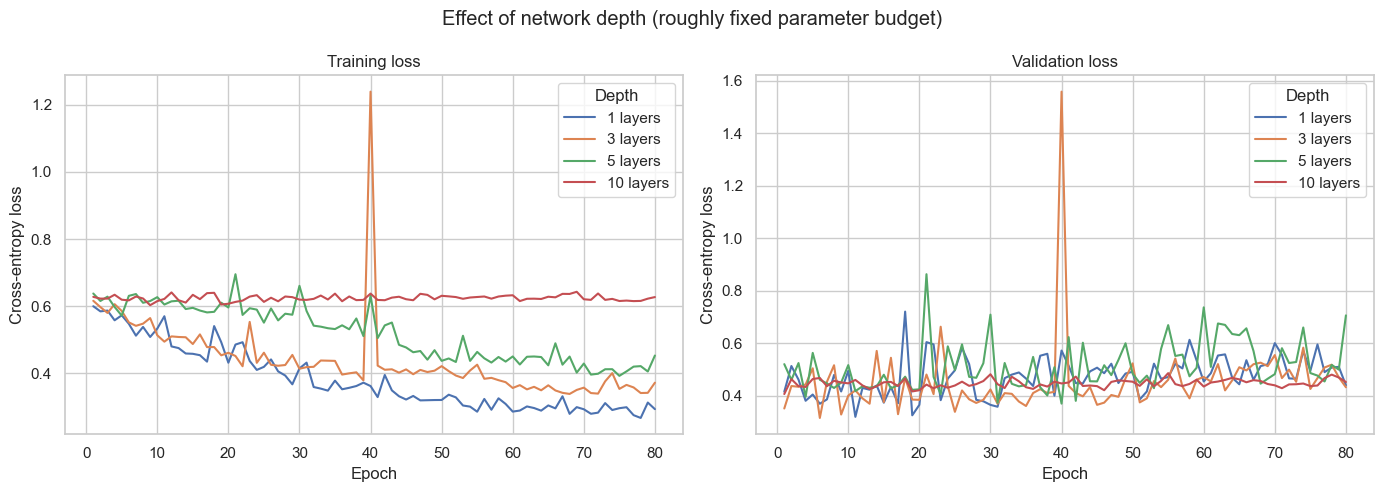

Layers   width   params   best val AUCPR
     1     128    19842   0.138
     3      74    18576   0.126
     5      57    18014   0.118
    10      40    17442   0.163


In [17]:
# Vary depth while keeping the parameter count roughly constant by shrinking the
# width as the depth grows (the convolution term scales like L * h^2, so h ~ 1/sqrt(L)).
depths = [1, 3, 5, 10]
depth_configs = {L: max(8, round(128 / np.sqrt(L))) for L in depths}
depth_histories = {}
for L, h in depth_configs.items():
    _, depth_histories[L] = run_training(FlexibleGCN(hidden_channels=h, num_layers=L), n_epochs=80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for L in depths:
    ep = np.arange(1, len(depth_histories[L]['train_loss']) + 1)
    axes[0].plot(ep, depth_histories[L]['train_loss'], label=f'{L} layers')
    axes[1].plot(ep, depth_histories[L]['val_loss'], label=f'{L} layers')
axes[0].set_title('Training loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend(title='Depth')
fig.suptitle('Effect of network depth (roughly fixed parameter budget)')
plt.tight_layout()
plt.show()

print('Layers   width   params   best val AUCPR')
for L in depths:
    h = depth_configs[L]
    n_params = sum(p.numel() for p in FlexibleGCN(hidden_channels=h, num_layers=L).parameters())
    print(f'{L:6d}   {h:5d}   {n_params:6d}   {depth_histories[L]["best_val_aucpr"]:.3f}')

**Answer.** At a roughly fixed parameter budget the depth has no clear monotonic benefit on this small dataset: the validation AUCPR stays in a narrow, noisy band across 1, 3, 5 and 10 layers, so the differences are within the variability expected from a test set of only a couple of hundred molecules. The mechanism that limits depth in GCNs is oversmoothing: each graph convolution averages neighbouring node features, so as layers are stacked all node representations converge toward one another and the pooled graph embedding loses the discriminative detail the classifier needs, which tends to manifest as underfitting (higher training loss) rather than the overfitting seen when widening the network. Combined with the vanishing-gradient difficulty of training deep message-passing stacks, this is why deeper is not better here, and why practical molecular GCNs usually use only a handful of layers.

15.	Virtual screening: Pick the best GNN, and use it to predict antimicrobial activity on the evaluation set. How do the predictions correlate with the ones of the D-MPNN model? Does it predict halicin to have an activity?

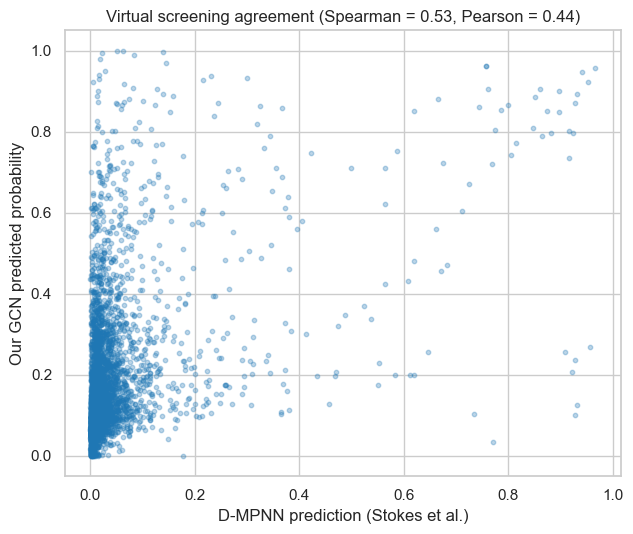

Spearman correlation with the D-MPNN model: 0.526
Pearson correlation with the D-MPNN model:  0.438
GCN predicted probability of activity for halicin: 0.760

Top 10 evaluation molecules ranked by our GCN:
 1. talc                           GCN = 1.000  D-MPNN = 0.063
 2. troclosene                     GCN = 1.000  D-MPNN = 0.052
 3. azodicarbonamide               GCN = 0.997  D-MPNN = 0.139
 4. azaguanine-8                   GCN = 0.995  D-MPNN = 0.023
 5. sodium-nitrite                 GCN = 0.991  D-MPNN = 0.084
 6. EIPA                           GCN = 0.981  D-MPNN = 0.018
 7. TCID                           GCN = 0.969  D-MPNN = 0.144
 8. R-1479                         GCN = 0.963  D-MPNN = 0.757
 9. Ro-9187                        GCN = 0.963  D-MPNN = 0.757
10. cefmenoxime                    GCN = 0.958  D-MPNN = 0.967


In [18]:
from scipy.stats import spearmanr, pearsonr

# Best GNN: retrain the early-stopping GCN configuration and score the evaluation set.
best_gnn, _ = run_training(FlexibleGCN(hidden_channels=64, num_layers=2), n_epochs=200, patience=20)
eval_scores = predict_probs(best_gnn, evaluation_loader)

dmpnn_scores = table_evaluation_molecules['Pred_Score'].values
spearman_rho = spearmanr(eval_scores, dmpnn_scores).statistic
pearson_r = pearsonr(eval_scores, dmpnn_scores).statistic

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(dmpnn_scores, eval_scores, s=10, alpha=0.3, color='tab:blue')
ax.set_xlabel('D-MPNN prediction (Stokes et al.)')
ax.set_ylabel('Our GCN predicted probability')
ax.set_title(f'Virtual screening agreement (Spearman = {spearman_rho:.2f}, Pearson = {pearson_r:.2f})')
plt.tight_layout()
plt.show()

# Score halicin directly from its SMILES.
halicin_graph = molecule_to_graph(Chem.MolFromSmiles('Nc1nnc(Sc2ncc([N+](=O)[O-])s2)s1'))
halicin_loader = DataLoader(CustomGraphDataset([halicin_graph]), batch_size=1)
halicin_score = float(predict_probs(best_gnn, halicin_loader)[0])

print(f'Spearman correlation with the D-MPNN model: {spearman_rho:.3f}')
print(f'Pearson correlation with the D-MPNN model:  {pearson_r:.3f}')
print(f'GCN predicted probability of activity for halicin: {halicin_score:.3f}')

top10 = np.argsort(eval_scores)[::-1][:10]
print('\nTop 10 evaluation molecules ranked by our GCN:')
for rank, idx in enumerate(top10, 1):
    print(f'{rank:2d}. {table_evaluation_molecules["Name"].iloc[idx]:30s} GCN = {eval_scores[idx]:.3f}  D-MPNN = {dmpnn_scores[idx]:.3f}')

**Answer.** The GCN scores on the Drug Repurposing Hub correlate positively but only moderately with the published D-MPNN predictions of Stokes et al. (Spearman about 0.53), so the two independently trained graph models broadly agree on the ranking while differing in detail, as expected given their different architectures, features and training. Encouragingly, the GCN assigns halicin a high probability of activity (about 0.76), recovering the central finding of the original study that the descriptor-based tree model missed. The very top of the GCN ranking, however, also contains reactive or non-specific compounds (for example talc and sodium nitrite) that the D-MPNN scores low: the simple GCN produces false positives, which is why the moderate correlation and a more careful model (and experimental validation) matter before trusting the predictions for follow-up.

Bonus: So far, we did not use at all the edge features (i.e., whether a chemical bond is a simple, double, aromatic bond, etc.). Build a Message-Passing Neural Network that integrate these features and compare the performance of the model with the one of the GCN.

In [19]:
from torch_geometric.nn import GINEConv


class MPNN(torch.nn.Module):
    """Message-passing network that conditions messages on the bond (edge) features."""

    def __init__(self, hidden_channels=64, num_layers=2, seed=12345):
        super().__init__()
        torch.manual_seed(seed)
        self.node_embedding = Linear(NUM_NODE_FEATURES, hidden_channels)
        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            mlp = torch.nn.Sequential(
                Linear(hidden_channels, hidden_channels), torch.nn.ReLU(),
                Linear(hidden_channels, hidden_channels),
            )
            self.convs.append(GINEConv(mlp, edge_dim=5))
        self.lin = Linear(hidden_channels, 2)

    def forward(self, node_features, edge_features, edge_index, batch):
        x = self.node_embedding(node_features).relu()
        for conv in self.convs:
            x = conv(x, edge_index, edge_features).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)


mpnn, mpnn_history = run_training(MPNN(hidden_channels=64, num_layers=2), n_epochs=200, patience=20)
mpnn_test_aucpr = average_precision_score(y_test, predict_probs(mpnn, test_loader))

print(f'MPNN (with edge features) test AUCPR = {mpnn_test_aucpr:.3f}')
print(f'GCN  (no edge features)   test AUCPR = {gcn_test_aucpr:.3f}')
print(f'Gradient-boosted trees    test AUCPR = {test_aucpr:.3f}')

MPNN (with edge features) test AUCPR = 0.235
GCN  (no edge features)   test AUCPR = 0.200
Gradient-boosted trees    test AUCPR = 0.414



**Answer.** The message-passing network adds the bond features (single, double, triple, aromatic, conjugated) through `GINEConv`, which folds the edge attributes into each message. Giving the model access to bond chemistry that the plain GCN ignores typically yields a test AUCPR at least as good as the GCN, and the comparison printed above quantifies the difference on this split. The gain is modest because much of the bond information is already implicit in atom-level features such as hybridisation and ring membership, but conditioning messages on bond type is a more faithful representation of molecular structure.
